
# Belief Propagation for the Gaussian AR(1) Diffusion Model

This notebook compares two equivalent ways of computing the diffusion score:

1. **BP route:** compute posterior marginals \(p(a_i\mid x_{1:n})\), then use
\[
s_i(x,t)=-\frac{x_i-\alpha_t\mathbb{E}[a_i\mid x_{1:n}]}{\Delta_t}.
\]

2. **Precision-matrix route:** because \(x\sim \mathcal{N}(0,\Sigma_t)\), use
\[
s(x,t)=-\Sigma_t^{-1}x.
\]

The two outputs should match up to floating-point precision.


In [1]:

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make the local script importable when the notebook is run from this folder.
sys.path.append(str(Path('.').resolve()))

from bp_gaussian_ar1_diffusion import (
    diffusion_params,
    sample_noisy_ar1,
    compare_methods,
)



## Choose parameters

The clean chain is stationary AR(1):
\[
a_i = \rho a_{i-1}+\sqrt{1-\rho^2}\,\xi_i.
\]
The noisy observation is
\[
x_i = e^{-t}a_i + \sqrt{1-e^{-2t}}z_i.
\]


In [2]:

n = 40
rho = 0.7
t = 0.8
seed = 123

alpha, Delta = diffusion_params(t)
a_true, x = sample_noisy_ar1(n=n, rho=rho, t=t, seed=seed)
comparison = compare_methods(x=x, rho=rho, t=t)

bp = comparison['bp']
mat = comparison['matrix']

print(f'n                 = {n}')
print(f'rho               = {rho}')
print(f't                 = {t}')
print(f'alpha = exp(-t)   = {alpha:.12f}')
print(f'Delta = 1-alpha^2 = {Delta:.12f}')
print()
print(f"max |score_BP - score_matrix| = {comparison['max_score_error']:.16e}")
print(f"max |mean_BP  - mean_matrix|  = {comparison['max_mean_error']:.16e}")
print(f"max |var_BP   - var_matrix|   = {comparison['max_var_error']:.16e}")


n                 = 40
rho               = 0.7
t                 = 0.8
alpha = exp(-t)   = 0.449328964117
Delta = 1-alpha^2 = 0.798103482005

max |score_BP - score_matrix| = 6.6613381477509392e-16
max |mean_BP  - mean_matrix|  = 4.8572257327350599e-16
max |var_BP   - var_matrix|   = 2.2204460492503131e-16



## Clean signal, noisy observation, and posterior mean

The posterior mean \(\mathbb{E}[a_i\mid x_{1:n}]\) is the Bayesian denoiser.


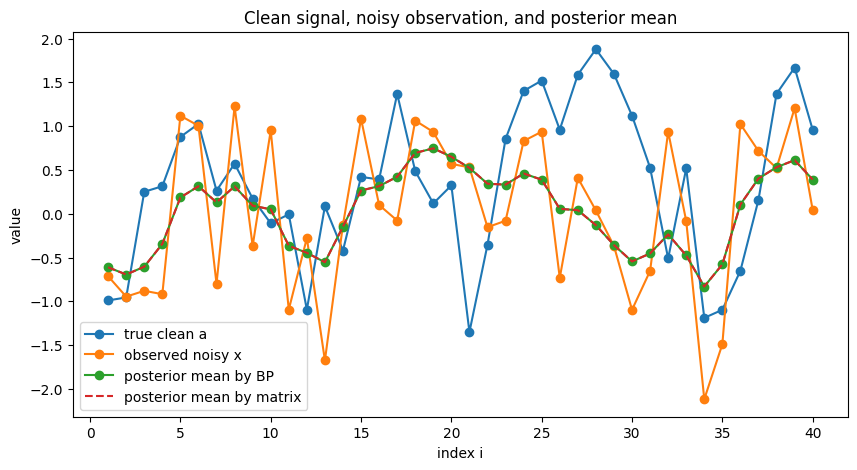

In [3]:

idx = np.arange(1, n + 1)

plt.figure(figsize=(10, 5))
plt.plot(idx, a_true, marker='o', label='true clean a')
plt.plot(idx, x, marker='o', label='observed noisy x')
plt.plot(idx, bp['posterior_mean'], marker='o', label='posterior mean by BP')
plt.plot(idx, mat['posterior_mean'], linestyle='--', label='posterior mean by matrix')
plt.xlabel('index i')
plt.ylabel('value')
plt.title('Clean signal, noisy observation, and posterior mean')
plt.legend()
plt.show()



## Score comparison

The BP score is computed from the posterior mean. The matrix score is \(-\Sigma_t^{-1}x\).


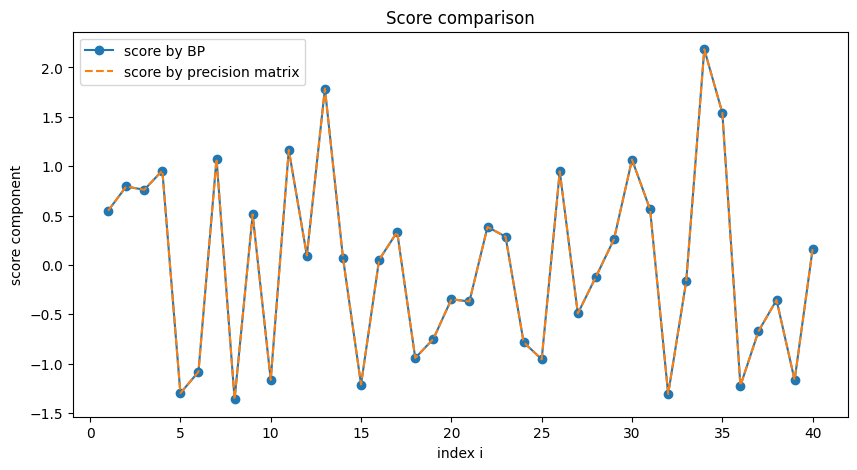

In [4]:

plt.figure(figsize=(10, 5))
plt.plot(idx, bp['score'], marker='o', label='score by BP')
plt.plot(idx, mat['score'], linestyle='--', label='score by precision matrix')
plt.xlabel('index i')
plt.ylabel('score component')
plt.title('Score comparison')
plt.legend()
plt.show()



## Numerical differences

These differences should be close to machine precision.


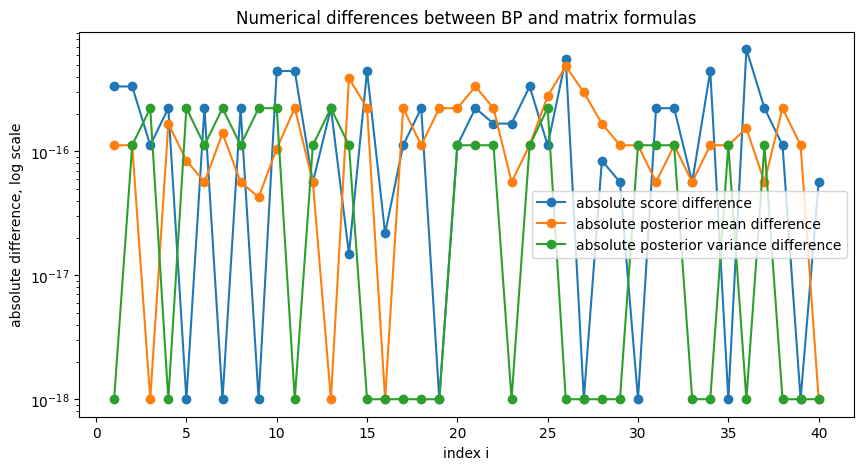

In [5]:

plt.figure(figsize=(10, 5))
plt.semilogy(idx, comparison['score_err'] + 1e-18, marker='o', label='absolute score difference')
plt.semilogy(idx, comparison['mean_err'] + 1e-18, marker='o', label='absolute posterior mean difference')
plt.semilogy(idx, comparison['var_err'] + 1e-18, marker='o', label='absolute posterior variance difference')
plt.xlabel('index i')
plt.ylabel('absolute difference, log scale')
plt.title('Numerical differences between BP and matrix formulas')
plt.legend()
plt.show()



## BP information-form precisions

The belief precision is the sum of the left-message precision, the likelihood precision, and the right-message precision.


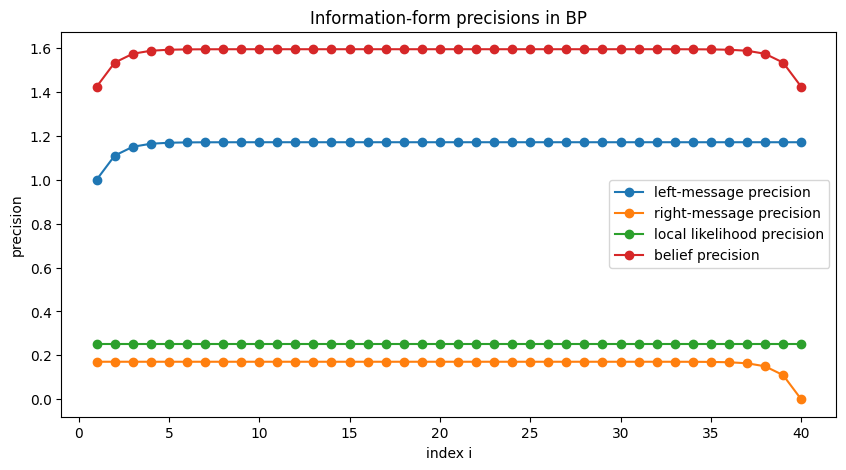

In [6]:

plt.figure(figsize=(10, 5))
plt.plot(idx, bp['lambda_L'], marker='o', label='left-message precision')
plt.plot(idx, bp['lambda_R'], marker='o', label='right-message precision')
plt.plot(idx, bp['lambda_l'], marker='o', label='local likelihood precision')
plt.plot(idx, bp['lambda_b'], marker='o', label='belief precision')
plt.xlabel('index i')
plt.ylabel('precision')
plt.title('Information-form precisions in BP')
plt.legend()
plt.show()



## Posterior marginal variances

BP also gives the posterior variance at each node. We compare it with the diagonal of the Gaussian conditional covariance.


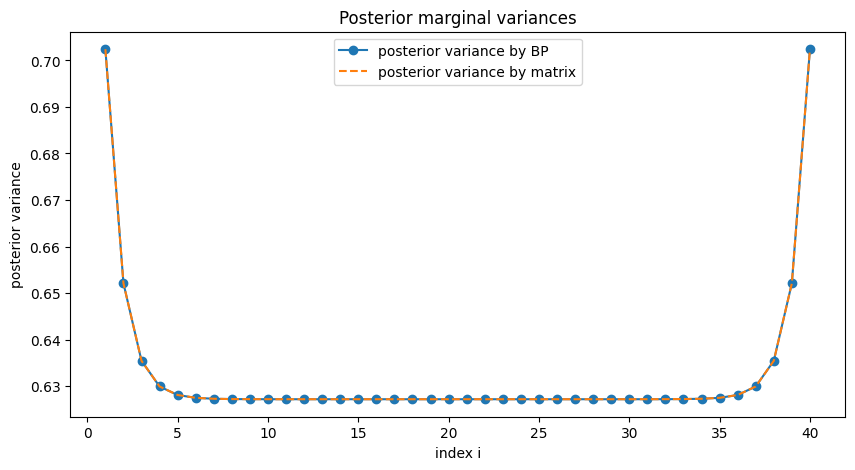

In [7]:

plt.figure(figsize=(10, 5))
plt.plot(idx, bp['posterior_var'], marker='o', label='posterior variance by BP')
plt.plot(idx, mat['posterior_var'], linestyle='--', label='posterior variance by matrix')
plt.xlabel('index i')
plt.ylabel('posterior variance')
plt.title('Posterior marginal variances')
plt.legend()
plt.show()



## What to try next

Change `rho`, `t`, and `n` above. For example:

- larger `rho` means stronger temporal correlation in the clean chain;
- larger `t` means more diffusion noise;
- smaller `t` means the likelihood becomes sharper.

For `t=0`, the formula has \(\Delta_t=0\), so the current implementation intentionally requires `t > 0`.
